In [1]:
import pickle
from cmdstanpy import CmdStanModel
import arviz as az

In [ ]:
model = CmdStanModel(stan_file='trape5.stan')
fit = model.sample(data='trape_individuals.json', show_console=False, show_progress=True, chains=4, parallel_chains=4)

print(fit.summary())

draws = fit.draws_pd()
draws.to_csv('trape5_draws.csv')
with open('trape5_fit.pickle', 'wb') as f:
    pickle.dump(fit, f)

14:02:38 - cmdstanpy - INFO - compiling stan file /home/njs/ownCloud/DocSyncUoE/CHMI/Malaria_Vaccination/Data_Fitting/Trape/trape5.stan to exe file /home/njs/ownCloud/DocSyncUoE/CHMI/Malaria_Vaccination/Data_Fitting/Trape/trape5
14:03:09 - cmdstanpy - INFO - compiled model executable: /home/njs/ownCloud/DocSyncUoE/CHMI/Malaria_Vaccination/Data_Fitting/Trape/trape5
14:03:09 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

14:03:49 - cmdstanpy - INFO - CmdStan done processing.
14:03:49 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'trape5.stan', line 62, column 4 to column 88)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'trape5.stan', line 62, column 4 to column 88)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'trape5.stan', line 62, column 4 to column 88)
	Exception: exponential_lpdf: Inverse scale parameter is 0, but must be positive finite! (in 'trape5.stan', line 59, column 4 to column 42)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'trape5.stan', line 62, column 4 to column 88)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape5.stan', line 69, column 16 to column 98)
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'trape5.stan', line 69, column 16 to column 98


                                 Mean      MCSE     StdDev           5%  \
lp__                      7372.230000  0.530215  17.287300  7343.320000   
lambda_tau_elp               1.003560  0.001748   0.118705     0.820254   
mu_delta_clinical_raw        1.780120  0.001116   0.061975     1.680150   
sigma_delta_clinical_raw     0.466715  0.001312   0.056473     0.377954   
tau_elp[1]                   0.873767  0.004660   0.381487     0.333312   
...                               ...       ...        ...          ...   
log_lik[634]                -2.143750  0.013191   0.722319    -3.570670   
log_lik[635]                -1.144860  0.003754   0.195330    -1.530920   
log_lik[636]                -0.726306  0.005015   0.363414    -1.422500   
log_lik[637]                -0.336500  0.003466   0.239017    -0.827713   
log_lik[638]                -0.074530  0.001356   0.085862    -0.251006   

                                  50%          95%    N_Eff   N_Eff/s  \
lp__                     

In [2]:
with open('trape5_fit.pickle', 'rb') as f:
    fit = pickle.load(f)
# print(fit.diagnose())

In [3]:
z = az.from_cmdstanpy(fit)
z

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [4]:
i = 1 # index of individual to extract: 1 to 111
vars = ['mu_delta_clinical_raw', 'sigma_delta_clinical_raw', 'lambda_tau_elp', 'lambda', 'tau_elp', 'delta_clinical', 'rho_clinical']
y = z.posterior.isel(lambda_dim_0=i, tau_elp_dim_0=i, delta_clinical_dim_0=i, rho_clinical_dim_0=i)

Rhat values good

In [5]:
print(az.rhat(y, var_names=vars))

<xarray.Dataset> Size: 88B
Dimensions:                   ()
Coordinates:
    tau_elp_dim_0             int64 8B 1
    rho_clinical_dim_0        int64 8B 1
    lambda_dim_0              int64 8B 1
    delta_clinical_dim_0      int64 8B 1
Data variables:
    mu_delta_clinical_raw     float64 8B 1.001
    sigma_delta_clinical_raw  float64 8B 1.001
    lambda_tau_elp            float64 8B 1.0
    lambda                    float64 8B 1.001
    tau_elp                   float64 8B 1.001
    delta_clinical            float64 8B 1.002
    rho_clinical              float64 8B 1.002


Effective samples sizes good

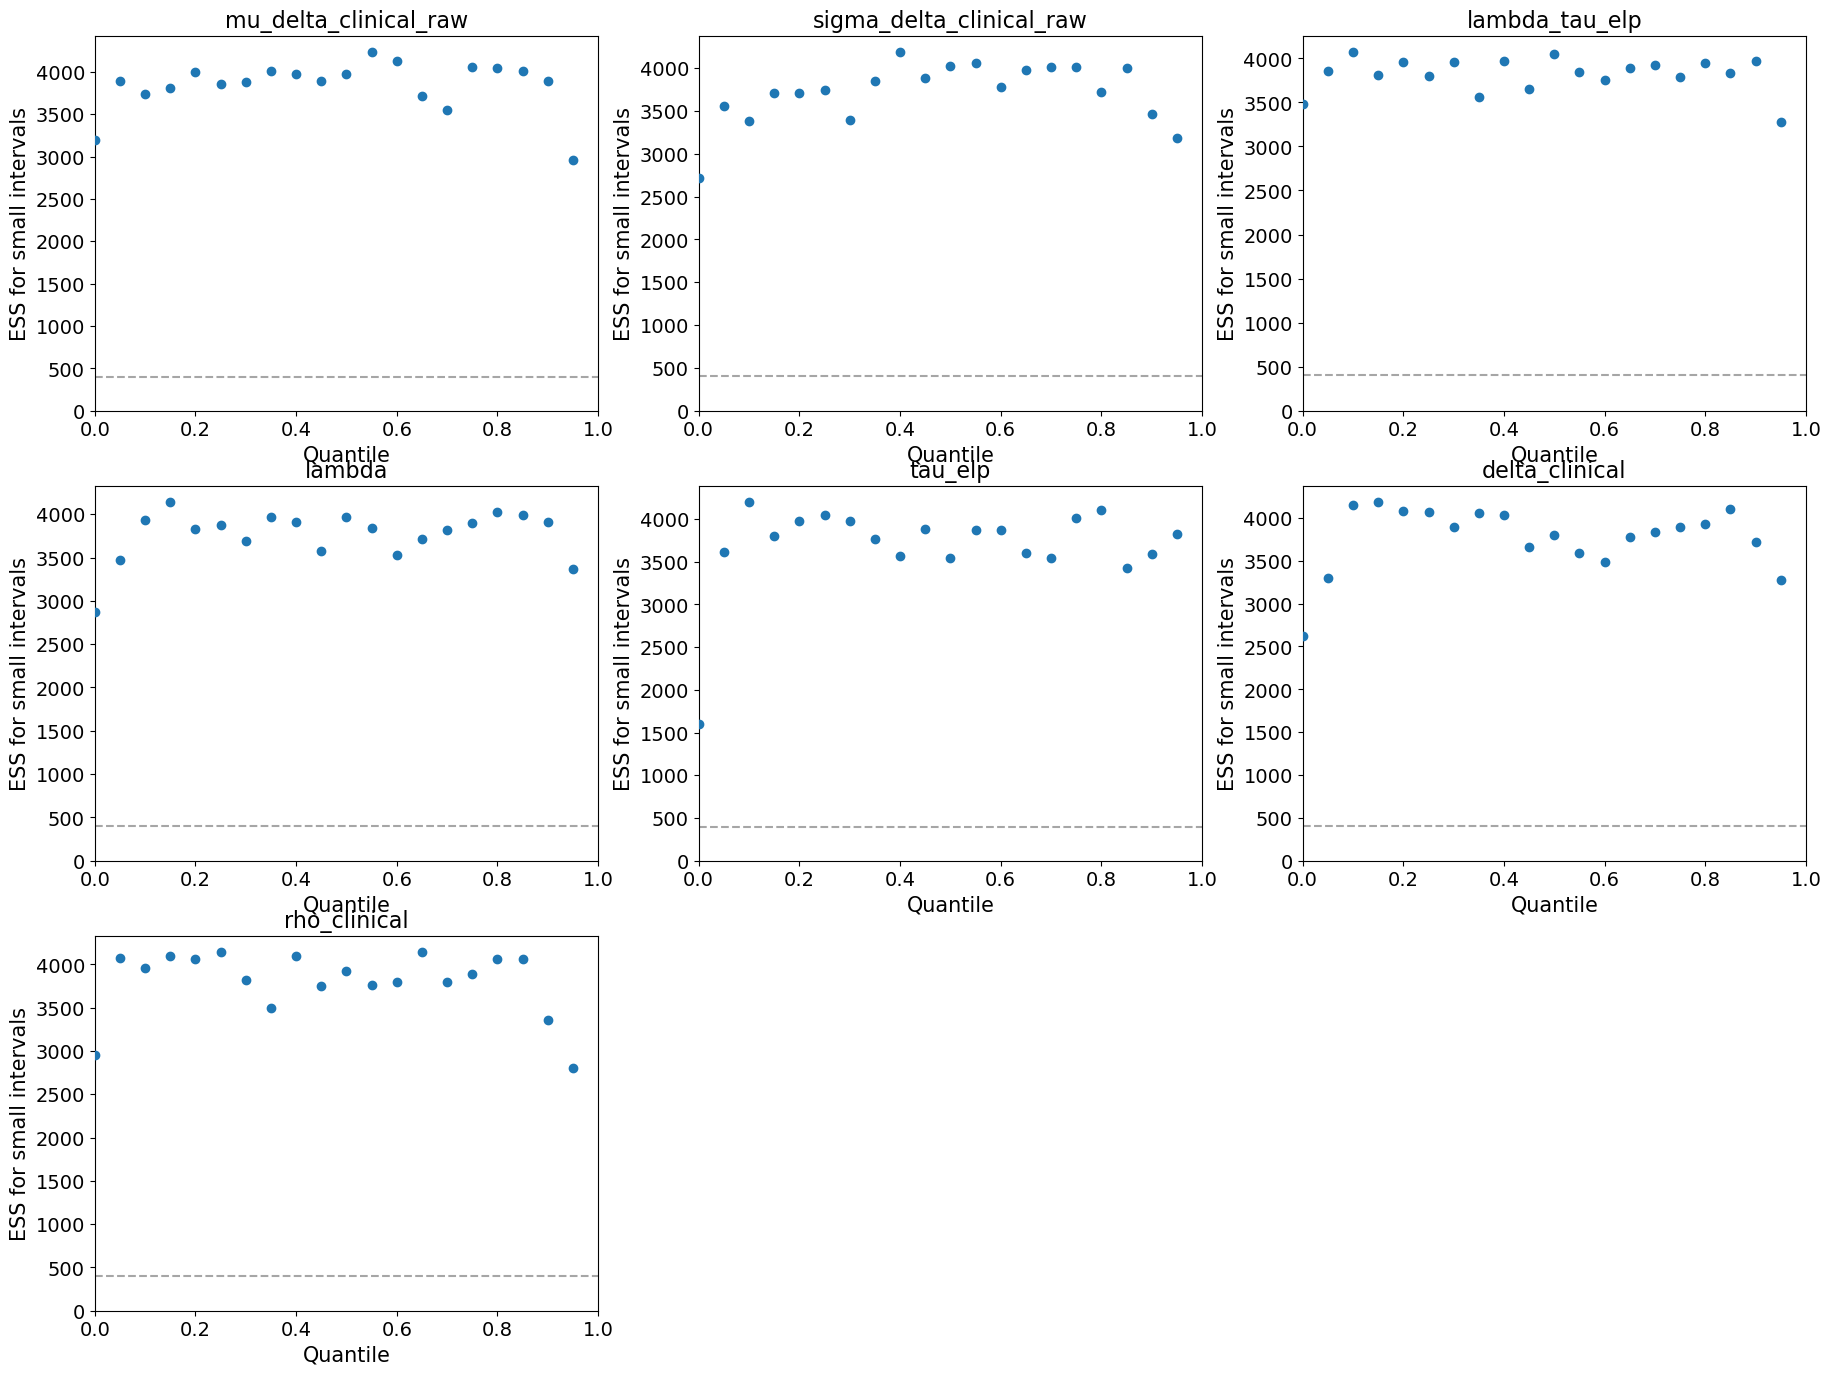

In [6]:
az.plot_ess(y, var_names=vars);

No major autocorrelation

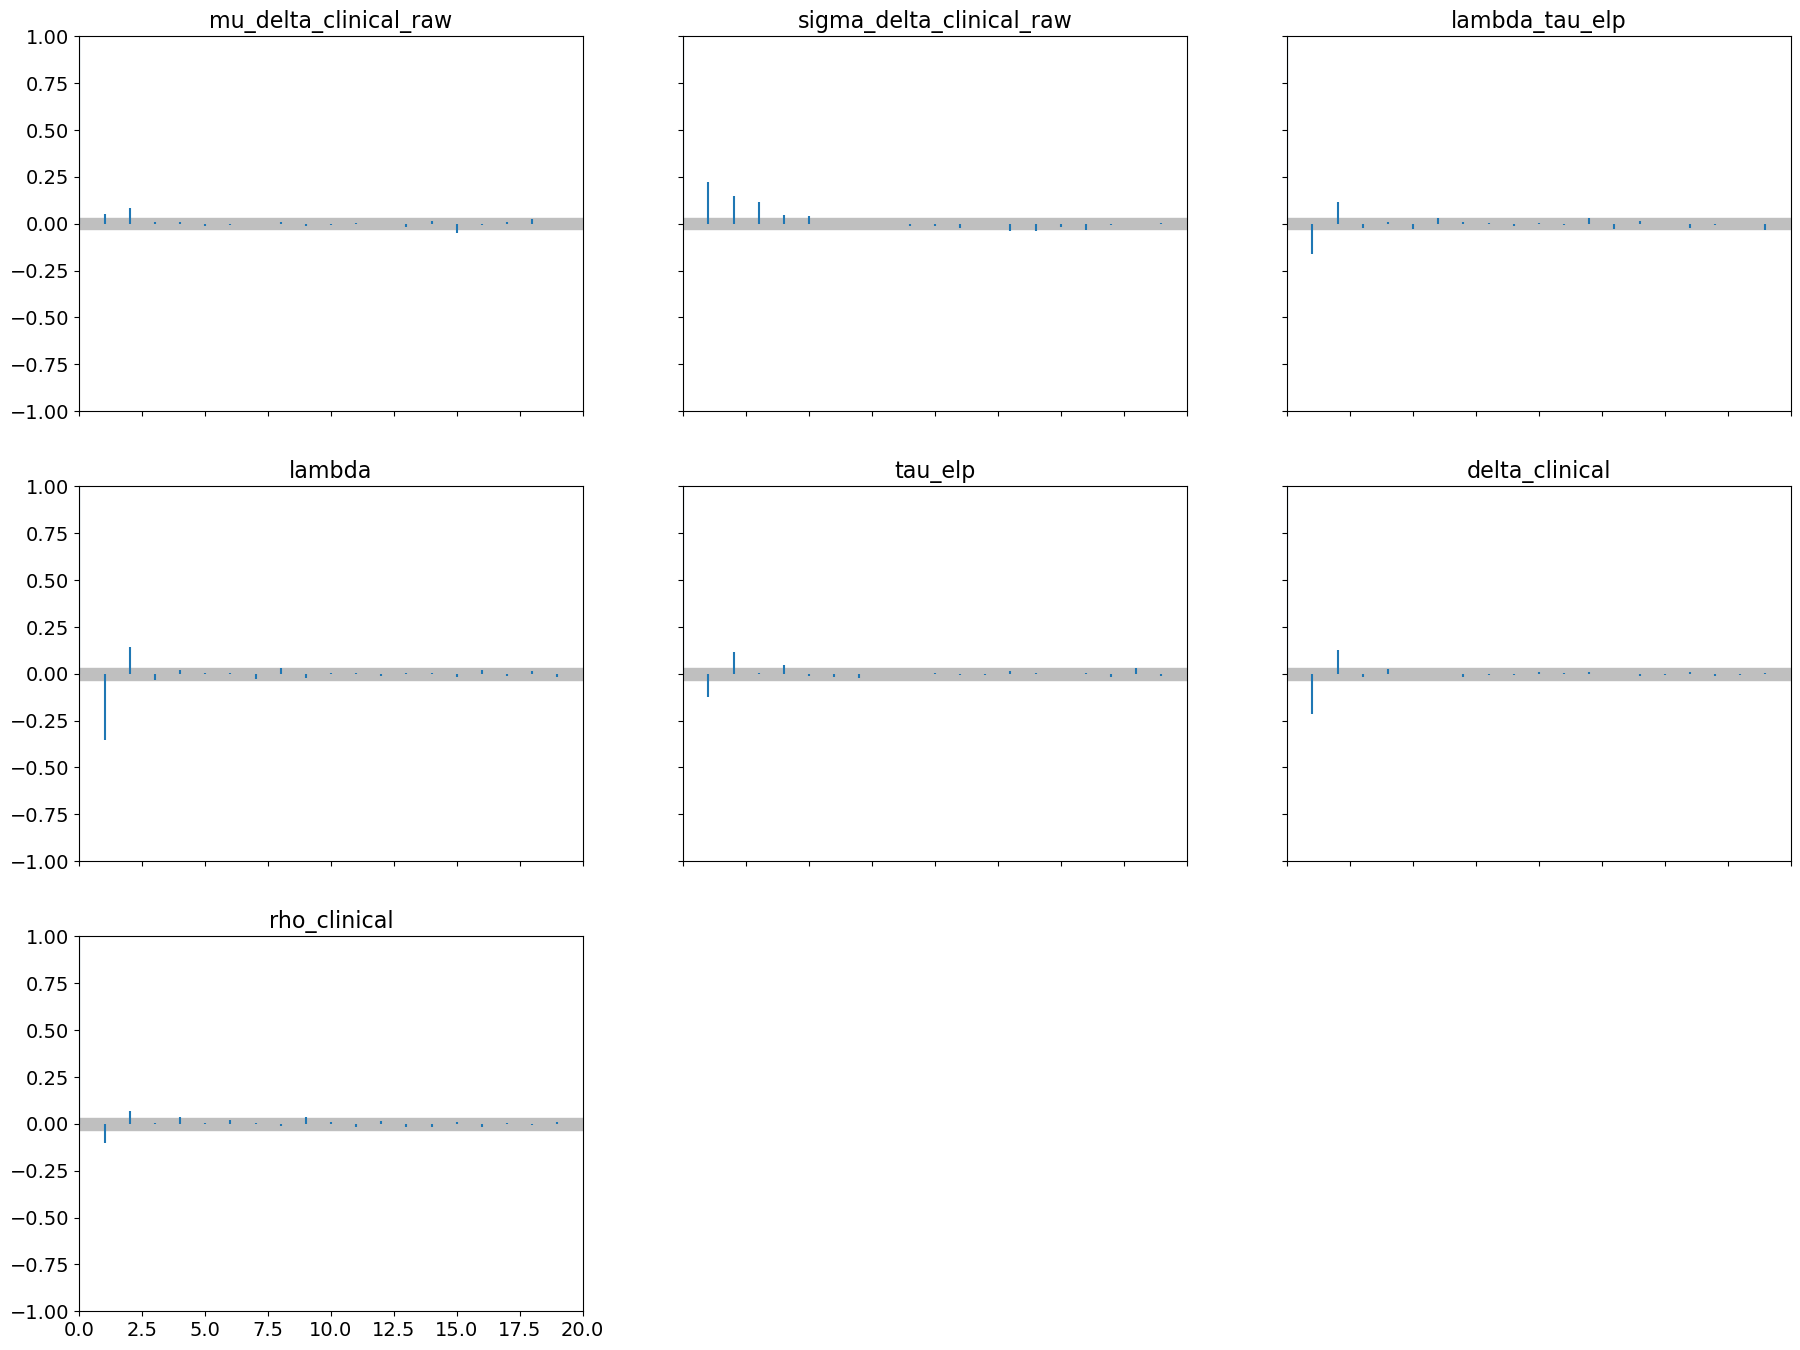

In [7]:
az.plot_autocorr(y, var_names=vars, combined=True, max_lag=20,);

Chains look good

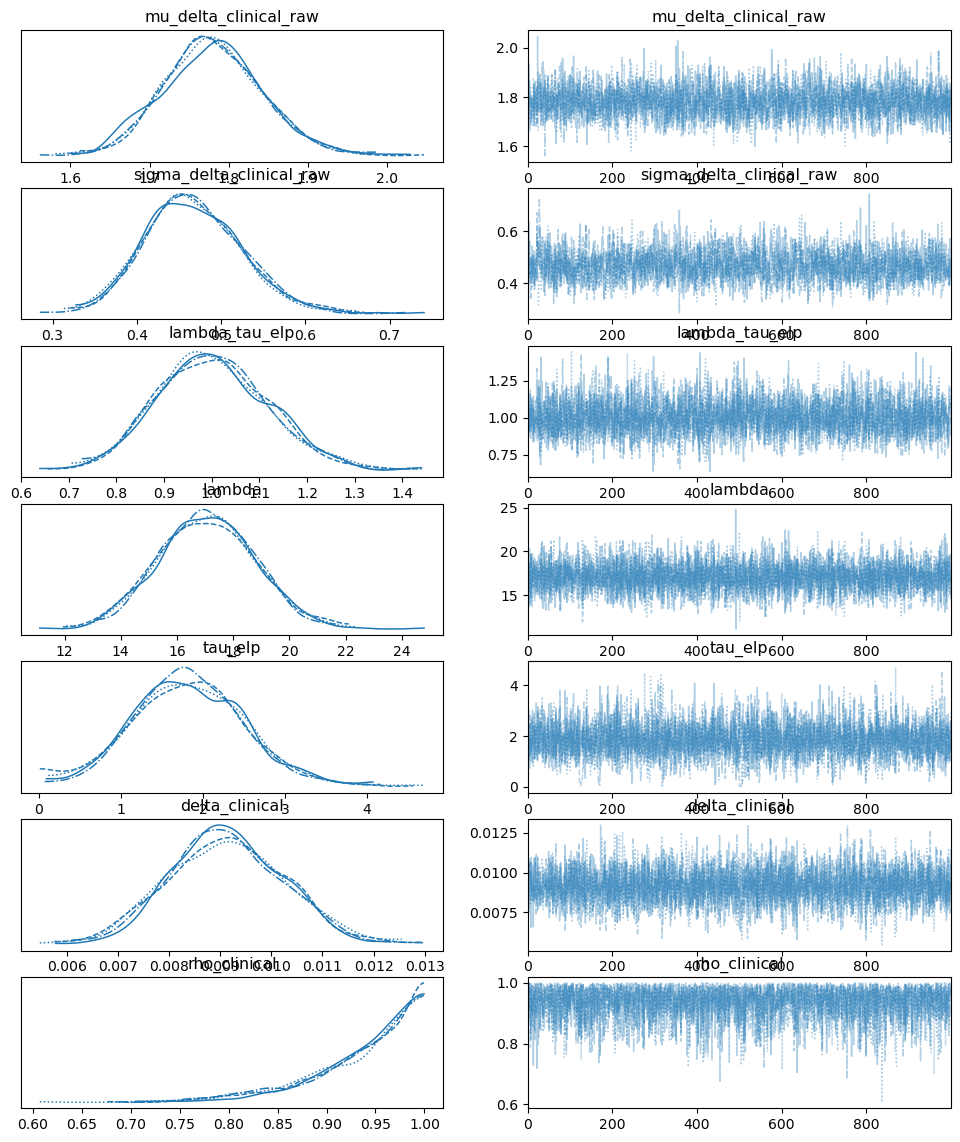

In [8]:
az.plot_trace(y, var_names=vars);

Pair plot reveals identifiability issue between rho and gamma

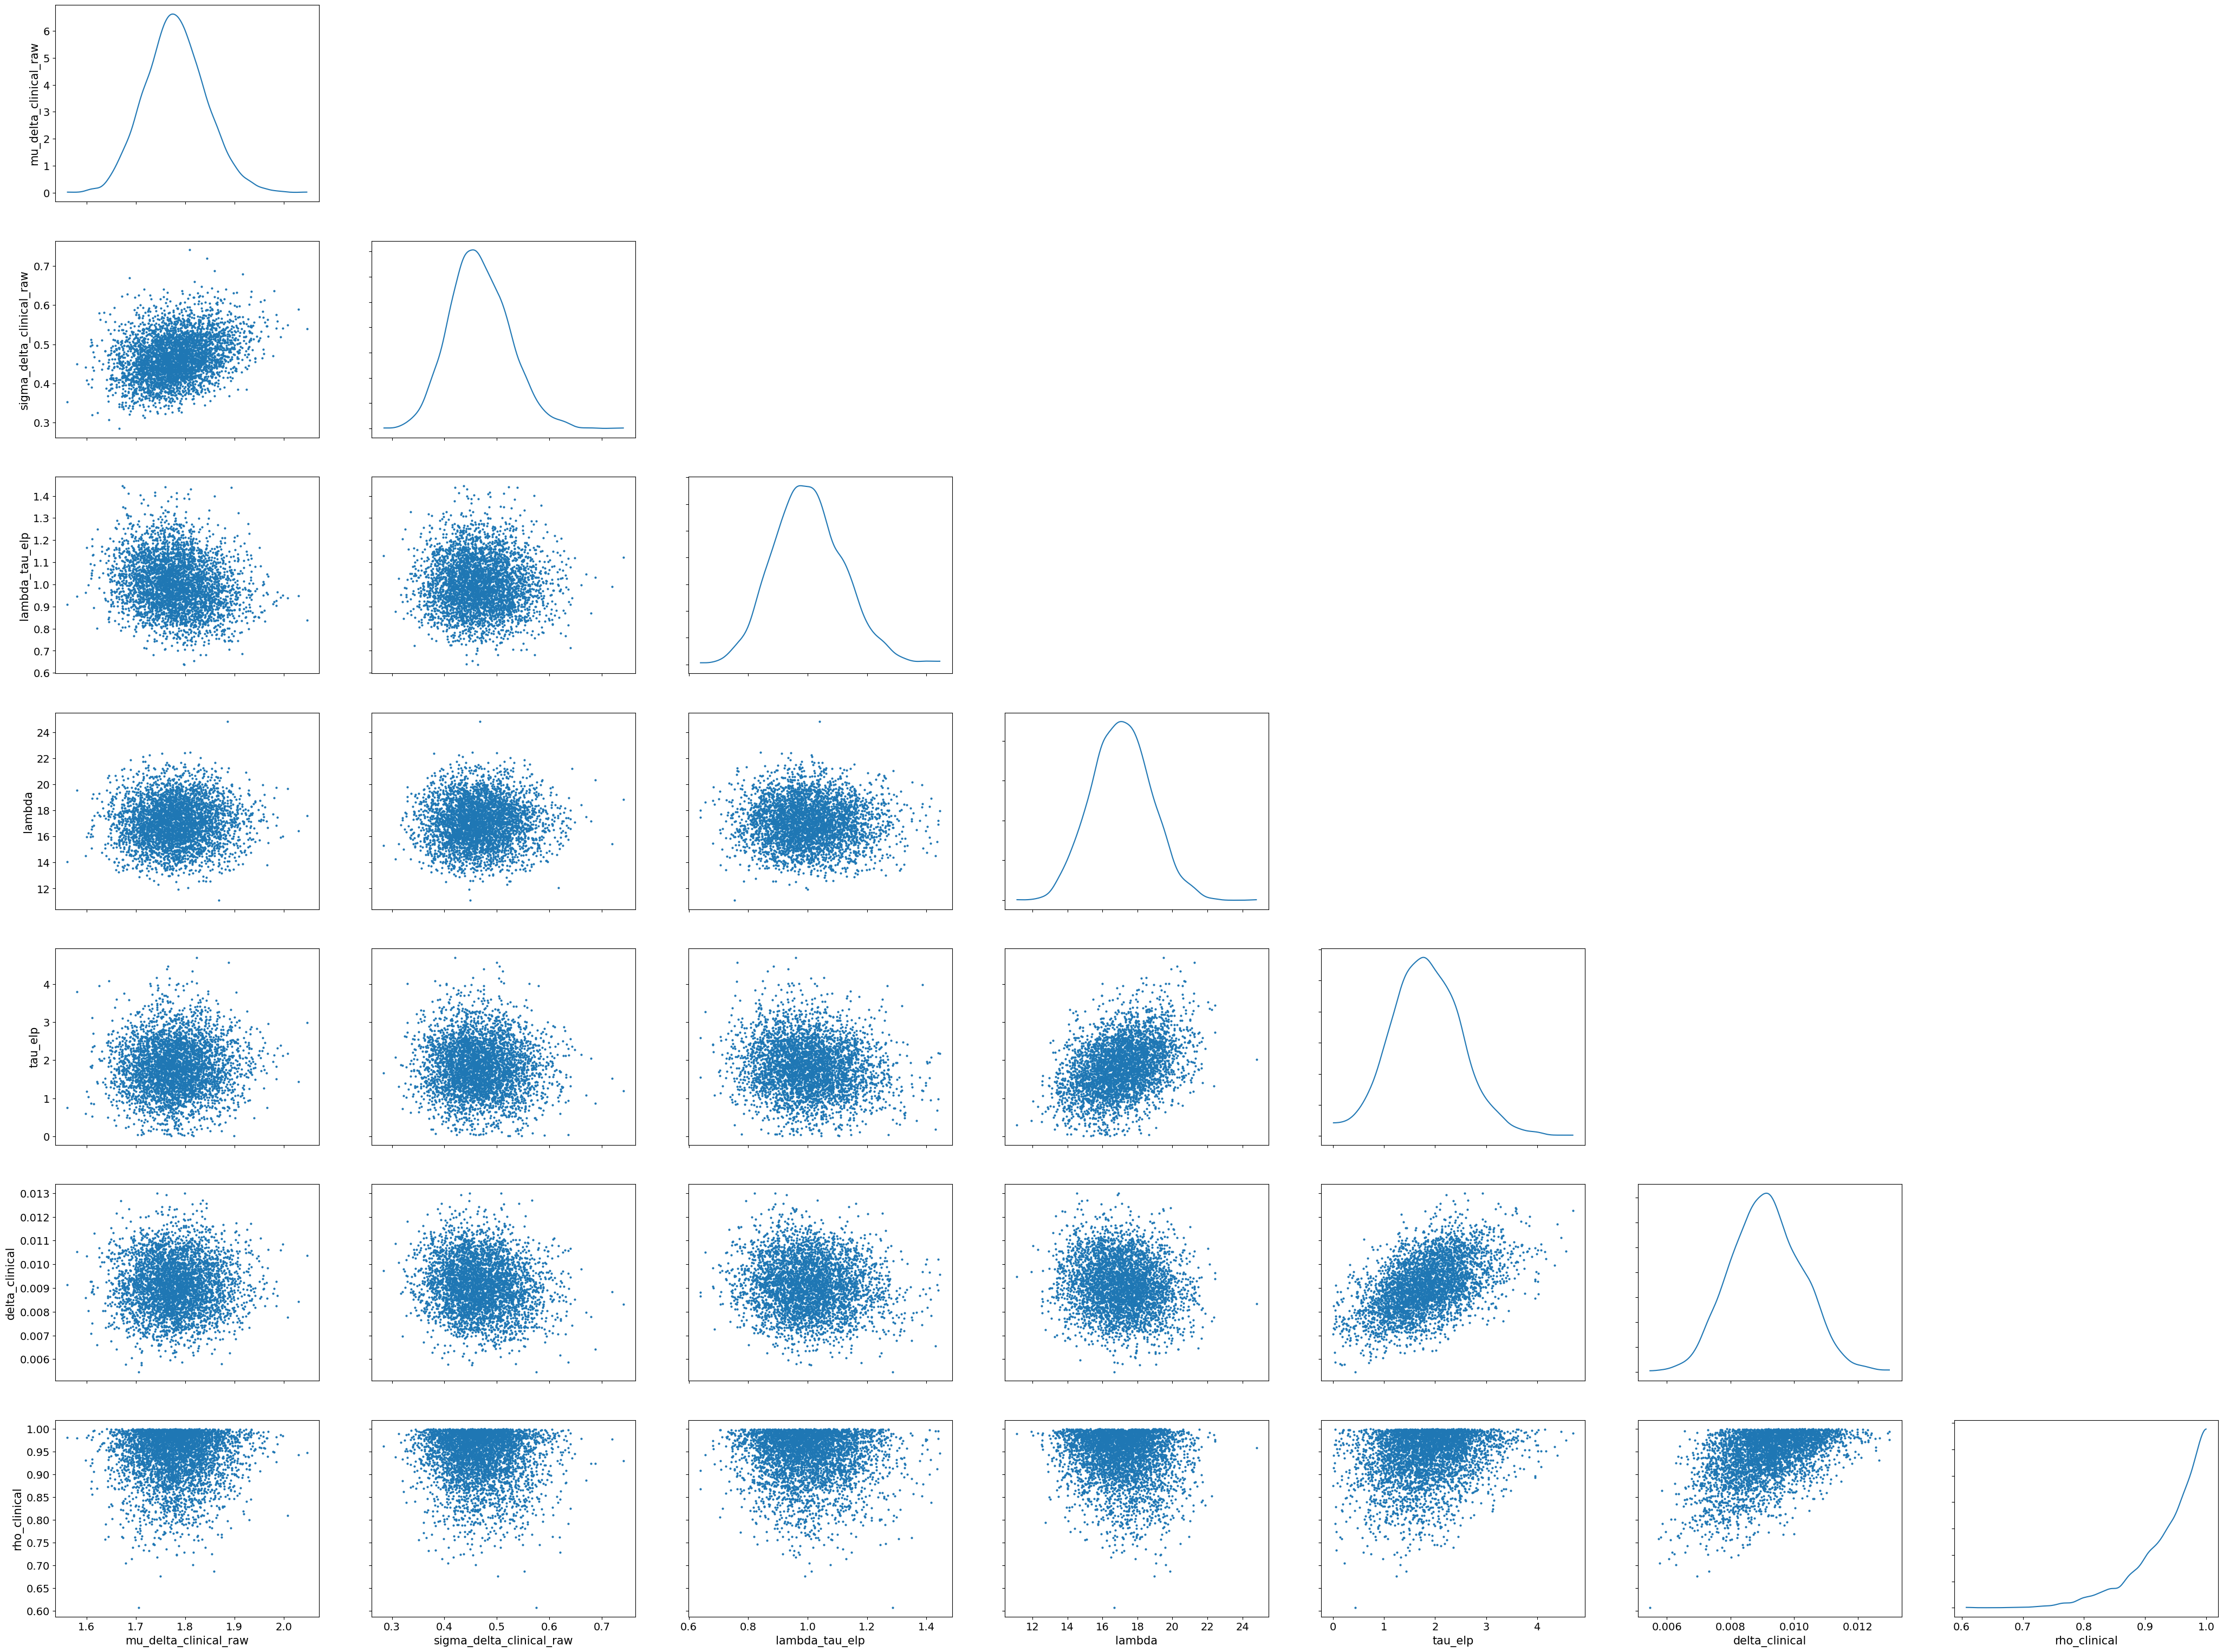

In [9]:
az.plot_pair(y, var_names=vars, marginals=True);